# Algorithmic Trading: Build a Momentum Strategy in Python
Digital Hub Insights LLC.

December 2025

Version: 5.0

Taught by: Cordell L. Tanny, CFA, FRM, FDP

Learn more about us: [digitalhub-labs.com](https://)


---



## Notebook 3: Coding a Full Backtest and Performance Analysis

In the previous notebook, we built a "simple backtest". It was a great first step that allowed us to quickly see that our momentum signal had merit. By averaging the returns of our top 10 ETFs each month, we got a high-level confirmation that the strategy was on the right track.

However, a simple backtest is not enough for a professional evaluation. It makes many optimistic assumptions and ignores the real-world frictions that can significantly impact a strategy's profitability. This notebook is about bridging that gap between a theoretical model and a practical simulation.

We are now going to build an event-driven backtester. This is a more complex but far more realistic approach. Instead of just looking at monthly returns, it simulates the trading process step-by-step, as if we were managing a real portfolio.

Why This Backtest is More Reliable

The simple backtest was a good proof of concept, but this full backtest is designed for reliability. Here is why this approach is superior:

- It Accounts for Real-World Costs: Our new backtester will explicitly model commissions (fees paid to a broker for executing a trade) and slippage (the difference between the expected price of a trade and the price at which the trade is actually executed). These costs are unavoidable in live trading and can significantly erode profits. Ignoring them leads to overly optimistic performance figures.

- It Tracks Positions and Cash: Instead of just averaging returns, this backtest starts with a specific amount of capital and simulates the actual purchase and sale of shares. It tracks how many shares of each ETF are held, how much cash is left in the portfolio, and what the total portfolio value is on any given day. This gives us a true day-by-day history of our strategy's value.

- It Creates a Detailed Log File: One of the most critical outputs will be a detailed transaction log. This log will record every single event: every buy order, every sell order, every commission paid, and the cash balance after each transaction. This level of detail is essential for debugging the strategy, understanding its turnover, and verifying that the logic is working exactly as intended. A strategy without a log is a black box; a strategy with a log is a transparent and auditable process.

The goal of this notebook is to move beyond a simple academic exercise and into the realm of professional quantitative analysis. By building this more robust engine, we can generate performance statistics that we can actually trust.








---
## Imports
- This cell installs and imports the necessary Python libraries for our analysis.

- We need specific tools for data manipulation `pandas`, numerical operations `numpy`, data visualization`matplotlib`, `seaborn`, and accessing our custom functions `functions` (please see the lecture videos that explain the `functions.py` file.

- We use pip to install any missing packages and standard import statements to make the libraries available in our notebook.



In [1]:
#!pip install -q pandas_market_calendars
import pandas as pd
import numpy as np
import random
from momentum_trading.core import functions as fn
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
#from google.colab import userdata
import pandas_market_calendars as mcal
from momentum_trading.backtest.momentum_backtest import run_custom_backtest, BacktestConfig

sns.set_theme()

# API Keys - set to None if not available
try:
    fmp_api_key = userdata.get('FMP_API_KEY')
except:
    fmp_api_key = None

try:
    eodhd_api_key = userdata.get('EODHD_API_KEY')
except:
    eodhd_api_key = None

### Load in the Data From Notebook 2
The most important part of this cell is that we are loading our saved work from Notebook 2. This is a critical concept in professional quantitative research. The process of generating a trading signal is computationally separate from the process of simulating the strategy. By saving our `top_etfs` "buy list" and the daily `df_prices_daily` to files, we create a clean separation.

- `top_etfs = pd.read_pickle('top_etfs_monthly.pkl')`: This line loads our monthly trading signal. We do not need to recalculate momentum or ranks; we simply load the result. This ensures our backtest is consistent and allows us to test different backtesting parameters (like commissions) without re-running the signal generation every time.

- `df_prices_daily = pd.read_pickle('df_prices_daily.pkl')`: We load the full daily OHLC (Open, High, Low, Close) price data for all ETFs. Our simple backtest only needed monthly closing prices, but a realistic backtester needs daily data to simulate trades happening on specific days and to track the portfolio's value accurately between rebalancing dates.

This separation of signal from simulation is not just for convenience; it is a core principle of good quantitative workflow. It makes our research more organized, repeatable, and less prone to errors.


*Note: Please pay attention to the suffix. I have made everything flexible so that if you go back to notebook 2 and try a different holding period and lookback period, you wouldn't need to change anything here, other than supplying the correct arguments.
The suffix '12-1' indicates a 12-month lookback period and 1-month holding period. You should have named the file `top_etfs_monthly_12-1.pkl' had you followed the previous notebook.*


In [2]:
# --- Load Data ---
# This assumes you have already created these files in a previous step.
suffix = '12-1'
try:
    daily_prices = pd.read_pickle('df_prices_daily.pkl')
    top_etfs_monthly = pd.read_pickle(f'top_etfs_monthly_{suffix}.pkl')
    print(f"Successfully loaded daily_prices.pkl and top_etfs_monthly_{suffix}.pkl")
except FileNotFoundError:
    print(f"Error: Make sure 'daily_prices.pkl' and 'top_etfs_monthly_{suffix}.pkl' are uploaded to this session.")
    # Create empty placeholders to prevent further errors
    daily_prices = pd.DataFrame()
    top_etfs_monthly = pd.Series()

Successfully loaded daily_prices.pkl and top_etfs_monthly_12-1.pkl


## The Event-Driven Backtesting Engine

This is the most important function in the entire course. It is a full, event-driven backtesting engine that simulates our momentum strategy with a much higher degree of realism than the simple model in Notebook 2.

Instead of just averaging monthly returns, this engine operates like a real portfolio manager. It starts with a fixed amount of cash, loops through each trading day, and makes decisions only when a rebalancing day is triggered. It tracks every share, every trade, and every dollar.

**Why This Approach is More Reliable**

The simple backtest ignored real-world frictions. This engine embraces them.

- State Management with the portfolio Dictionary: The backtest is built around a central portfolio dictionary. This is the "state" of our simulation. It holds the most current information at all times:

    - cash: How much money is available to trade.

    - holdings: A dictionary showing which ETFs are currently owned and how many shares of each.

    - total_value: The daily mark-to-market value of the entire portfolio (cash + value of all holdings).

- Simulating Trade Execution:

    - On a rebalance day, the code first determines which ETFs to sell (those no longer in the top 10) and which to buy (the new top 10).

    - It simulates selling old positions first, adding the proceeds (minus costs) back to the cash balance.

    - It then calculates how many shares of the new ETFs to buy based on an equal-weight target and the available cash.

    - Crucially, all trade prices are adjusted for slippage and all transactions have commissions deducted, using the parameters we defined earlier. This directly models the costs of trading.

- The Importance of the trade_log:

    - This is the single most critical output for verifying a strategy. Every time a trade is simulated (a buy or a sell), a detailed entry is added to the trade_log.

    - This log is our audit trail. It shows the date, ticker, action (BUY/SELL), number of shares, price, commission, and resulting cash balance for every single event.

    - Without a log, a backtest is a "black box" that produces a performance number. With a log, we have a transparent, verifiable record that proves our logic is working correctly and allows us to analyze the strategy's trading behavior, such as its turnover rate.

- Daily Portfolio Valuation:

    - Between rebalancing dates, the loop continues to run for every single trading day.

    - On these non-rebalance days, no trades occur, but the engine still calculates the total_value of the portfolio based on that day's closing prices.

    - This "mark-to-market" process gives us a true daily equity curve, allowing us to accurately measure volatility, drawdowns, and other critical risk metrics, which is impossible with a simple monthly-return backtest.

This event-driven approach is far more complex to code, but the results are significantly more trustworthy and representative of how a strategy would perform in the real world.

In [3]:
import numpy as np

def simulate_cap_division(tickers: list[str], capital: float, alpha: float = 1.0) -> dict:
    """
    Reparto aleatorio vectorizado utilizando la distribución de Dirichlet.
    Utiliza el método de 'Largest Remainder' para garantizar la suma exacta.
    """
    n = len(tickers)
    # Generar muestras aleatorias de Dirichlet (proporciones que suman 1.0)
    # alpha controla la dispersión: alpha=1.0 es distribución plana
    proporciones = np.random.dirichlet([alpha] * n)
    
    # Calcular montos crudos
    montos = proporciones * capital
    
    # Redondear y calcular el error de suma acumulado
    montos_int = np.floor(montos * 100) / 100  # Mantener 2 decimales
    diferencia = round(capital - np.sum(montos_int), 2)
    
    # Identificar cuánto falta para completar el capital total
    # Distribuir el sobrante en los tickers con mayor residuo decimal
    # Esto asegura que la suma sea perfecta sin sesgar la aleatoriedad
    num_centavos = int(round(diferencia * 100))
    if num_centavos > 0:
        residuos = (montos * 100) - (montos_int * 100)
        # Obtener los índices de los mayores residuos
        idx_ajuste = np.argsort(residuos)[-num_centavos:]
        montos_int[idx_ajuste] += 0.01
        
    return {ticker: float(round(monto, 2)) for ticker, monto in zip(tickers, montos_int)}

# --- Ejemplo de alto rendimiento ---
tickers_list = list(set(map(lambda x: x[0], daily_prices.columns)))
target_weights = simulate_cap_division(tickers=tickers_list, capital=100_000.0, alpha=1.0)

In [4]:
# NOTE: the naive inline run_custom_backtest(...) previously defined here has been
# removed. The strategy now lives in momentum_backtest.py (imported in the setup cell
# above) so there's a single source of truth instead of two divergent copies.
# See BacktestConfig for the risk-managed version's parameters.


In [5]:
cfg = BacktestConfig(
    # --- account basics ---
    holding_period=1,                 # monthly rebalance, matches signal frequency
    initial_capital=1_000.00,
    commission=0.0,                   # most brokers are $0 commission on ETFs today
    exchange="NYSE",

    # --- position sizing / risk ---
    vol_lookback_days=63,             # ~3 months trailing vol for inverse-vol weights
    target_portfolio_vol=0.15,        # 15% annualized, reasonable for equity-ETF rotation
    portfolio_vol_lookback=21,        # ~1 month realized vol estimate
    max_gross_exposure=1.0,           # no leverage, appropriate at this account size
    min_gross_exposure=0.25,          # floor so it doesn't fully flatline in a downtrend
    max_position_weight=0.35,         # cap any single ETF, with top_n~10 picks, 35% is generous headroom
    stop_loss_pct=0.12,               # 12% per-position stop

    # --- regime filter ---
    use_regime_filter=True,
    regime_benchmark="SPY",
    regime_sma_window=150,            # slightly faster than classic 200D for monthly rebal

    # --- execution realism ---
    base_slippage_bps=2.0,            # liquid large ETFs, keep modest
    vol_slippage_multiplier=0.5,
    random_seed=42,

    # --- turnover / cost control ---
    drift_threshold=0.03,             # skip rebalancing trades under 3% drift
    min_trade_size=25.0,              # skip trades under $25, sized for $1,000 capital

    # --- cash flow ---
    monthly_contribution=0.0,         # set >0 only if actually DCA-ing

    # --- logging ---
    log_file_path="trades_log.txt",
    allow_fractional_shares = True,
)

backtest_df = run_custom_backtest(top_etfs_monthly, daily_prices, **cfg.__dict__)
display(backtest_df.head())
print(backtest_df.attrs["tearsheet"])

2026-07-18 14:17:34,490 | INFO | Backtest period: 2006-01-31 to 2025-08-29 | 235 rebalance dates.


2026-07-18 14:17:37,743 | INFO | Backtest complete. Total commission: $0.00 | Total slippage cost (est.): $239.82


2026-07-18 14:17:37,763 | INFO | ============================================================


2026-07-18 14:17:37,764 | INFO | TEARSHEET


2026-07-18 14:17:37,765 | INFO | CAGR:                 7.21%


...

2026-07-18 14:17:37,772 | INFO | Total Est. Slippage:  $239.82


2026-07-18 14:17:37,772 | INFO | Total Turnover ($):   $229943.57


2026-07-18 14:17:37,773 | INFO | ============================================================


,Month End Portfolio Value,Month Beginning Portfolio Value,Portfolio Monthly Return,SPY Monthly Return,Portfolio Cumulative Return,SPY Cumulative Return
Date,,,,,,
2006-02-28,996.679780,1000.000000,-0.003320,0.005725,0.996680,1.005725
2006-03-31,1000.772255,996.679780,0.004106,0.012478,1.000772,1.018275
2006-04-30,1008.072252,1000.772255,0.007294,0.012632,1.008072,1.031137
2006-05-31,997.343043,1008.072252,-0.010643,-0.030121,0.997343,1.000078
2006-06-30,993.426258,997.343043,-0.003927,-0.001804,0.993426,0.998275


{'CAGR': np.float64(0.07207309703361342), 'AnnVol': np.float64(0.10545545847253887), 'Sharpe': np.float64(0.7144470032635162), 'Sortino': np.float64(1.0129301539312536), 'MaxDrawdown': np.float64(-0.27980039299135373), 'Calmar': np.float64(0.25758754754801433), 'WinRate': np.float64(0.5914893617021276), 'Beta': np.float64(0.42598666124816315), 'Alpha': np.float64(0.03495009253930469), 'TotalCommission': 0.0, 'TotalSlippage': np.float64(239.81695841338842), 'TotalTurnover': np.float64(229943.57069625094)}


We use the !head command to quickly peek at the first 20 lines of our log file. This isn't for deep analysis, but just to confirm what's inside and see how our log entries are formatted.

In [6]:
with open('trades_log.txt', 'r') as f:
    log_contents = f.read()


print(log_contents)

Backtest Start: 2006-02-01, Initial Capital: $1,000.00
Config: vol_target=0.15, max_position=0.35, stop_loss=0.12, regime_filter=True

--- Rebalance 2006-02-01 | Total Value $1,000.00 | Gross Exposure 25.0% (regime=0.25, vol_scalar=1.00) ---
BUY:  0.4401 GLD @ $56.80 (slip 2.0bps)
BUY:  0.3443 IWM @ $72.60 (slip 2.0bps)
BUY:  0.3363 IWV @ $74.33 (slip 2.0bps)
BUY:  0.5988 QQQ @ $41.75 (slip 2.0bps)
BUY:  1.1315 SOXX @ $22.09 (slip 2.0bps)
BUY:  0.3845 VBR @ $65.01 (slip 2.0bps)
BUY:  1.4659 VO @ $17.05 (slip 2.0bps)
BUY:  0.3924 VTI @ $63.70 (slip 2.0bps)
BUY:  0.8695 XLE @ $28.75 (slip 2.0bps)
BUY:  1.5481 XLU @ $16.15 (slip 2.0bps)

--- Rebalance 2006-03-01 | Total Value $999.75 | Gross Exposure 25.0% (regime=0.25, vol_scalar=1.00) ---
SELL: 0.3363 IWV @ $74.57 (slip 7.1bps)
BUY:  1.1545 XLF @ $26.61 (slip 7.5bps)

--- Rebalance 2006-04-03 | Total Value $1,000.90 | Gross Exposure 25.0% (regime=0.25, vol_scalar=1.00) ---
BUY:  0.4720 IWV @ $75.95 (slip 6.4bps)

--- Rebalance 2006-05-0

Let's take a look at the last few orws of the backtest results dataframe.
The goal here is to see the cumulative returns of both our strategy and SPY. We can see that our stratgy has beaten the benchmark!

And as noted, beating SPY is not an easy thing to do.


In [7]:
pd.concat([backtest_df.head(), pd.DataFrame([6*['----']], index=['----'], columns=backtest_df.columns), backtest_df.tail()]) 

,Month End Portfolio Value,Month Beginning Portfolio Value,Portfolio Monthly Return,SPY Monthly Return,Portfolio Cumulative Return,SPY Cumulative Return
2006-02-28 00:00:00,996.67978,1000.0,-0.00332,0.005725,0.99668,1.005725
2006-03-31 00:00:00,1000.772255,996.67978,0.004106,0.012478,1.000772,1.018275
2006-04-30 00:00:00,1008.072252,1000.772255,0.007294,0.012632,1.008072,1.031137
2006-05-31 00:00:00,997.343043,1008.072252,-0.010643,-0.030121,0.997343,1.000078
2006-06-30 00:00:00,993.426258,997.343043,-0.003927,-0.001804,0.993426,0.998275
----,----,----,----,----,----,----
2025-04-30 00:00:00,3397.207655,3399.04382,-0.00054,-0.00867,3.397208,4.349333
2025-05-31 00:00:00,3439.976779,3397.207655,0.012589,0.062845,3.439977,4.622667
2025-06-30 00:00:00,3658.624705,3439.976779,0.063561,0.048287,3.658625,4.845882
2025-07-31 00:00:00,3721.67271,3658.624705,0.017233,0.023032,3.721673,4.95749




---


## Creating the Tear Sheet

**What is a tear sheet?**

In finance, a tear sheet is a concise, one-page document that summarizes the key performance, risk, and statistical information for a trading strategy, hedge fund, or other investment.

Think of it as a "report card" for your strategy. It's designed to give a potential investor (or you, the analyst) a complete and standardized overview at a glance. It typically includes:

- Performance Metrics: Cumulative returns, annualized returns, and performance vs. a benchmark.

- Risk Metrics: Volatility (standard deviation), Sharpe ratio, Sortino ratio.

- Drawdown Analysis: The max drawdown (the peak-to-trough decline).

- Market Capture: How the strategy performed during market up-months (up-capture) vs. down-months (down-capture).

The functions.py file in your course is essentially a toolkit for building the most important components of a professional tear sheet.

### Isolating the Returns
The `functions.py` functions to produce the tear sheet require the periodic returns for the strategies. In this case, it is monthly returns.

Note that understanding all of the code in `functions.py` is outside the scope of this course. Feel free to go thorugh it with your favourite LLM!


In [8]:
# Isolate the monthly returns
backtest_monthly_returns = backtest_df[['Portfolio Monthly Return', 'SPY Monthly Return']]
backtest_monthly_returns.tail()

,Portfolio Monthly Return,SPY Monthly Return
Date,,
2025-04-30,-0.000540,-0.008670
2025-05-31,0.012589,0.062845
2025-06-30,0.063561,0.048287
2025-07-31,0.017233,0.023032
2025-08-31,0.049920,0.020520


### Creating the Tear Sheet

The `tear_sheet` function requires a number of arguments to be supplied:
1. We must provide both the `start_date` and `end_date` of the monthly returns. And they must be done as strings. We use the `.strftime` method to convert the datetime indexes to a string.

2. We must supply the `exchange` as a string. This is required by the `pandas_market_calendars` package which will provide all of the trading days during the investment horizon. This is needed to properly calculate the trailing returns.

3. We must also supply the `frequency` of the returns. In this case, we need `M` for monthly.

4. `annualize` is a boolean argument. `True` indicates we want all performance periods greater thqan 1 year to be annualized (the average annual return). `False` provides cumulative returns in every period greater than 1 year.

5. We must also let the function know which column in the returns dataframe contains the benchmark. Many of the metrics in the tear sheet require a benchmark for calculation. You must supply this as a string, and ensure it is exactly the same as the column label.

Please note that all functions in `functions.py` have complete docstrings to help you.

In [9]:
bt_start_date = datetime.strftime(backtest_monthly_returns.index[0], '%Y-%m-%d')
bt_end_date = datetime.strftime(backtest_monthly_returns.index[-1], '%Y-%m-%d')
tear_sheet = fn.tear_sheet(
    backtest_monthly_returns,
    start_date=bt_start_date,
    end_date=bt_end_date,
    exchange='NYSE',
    frequency='M',
    annualize=False,
    benchmark_col='SPY Monthly Return'
)

Data retrieved from Yahoo Finance for BIL


Now we can see how well we did across all metrics!
Please watch the associated lecture (Lecture 25) for a complete walkthrough of all metrics.

In [10]:
tear_sheet

,Portfolio Monthly Return,SPY Monthly Return
Return,7.21,8.63
Standard Deviation,10.55,15.27
1 Month,4.99,2.05
3 Month,13.59,9.44
6 Month,18.26,8.56
YTD,19.33,10.06
1 Year,28.92,14.44
3 Year,36.85,63.23
5 Year,58.39,84.66
10 Year,103.30,226.33


## Visualizing Performance
We can use the `cumulative_return_graph` function to create a line plot of how our strategy performed relative to SPY.

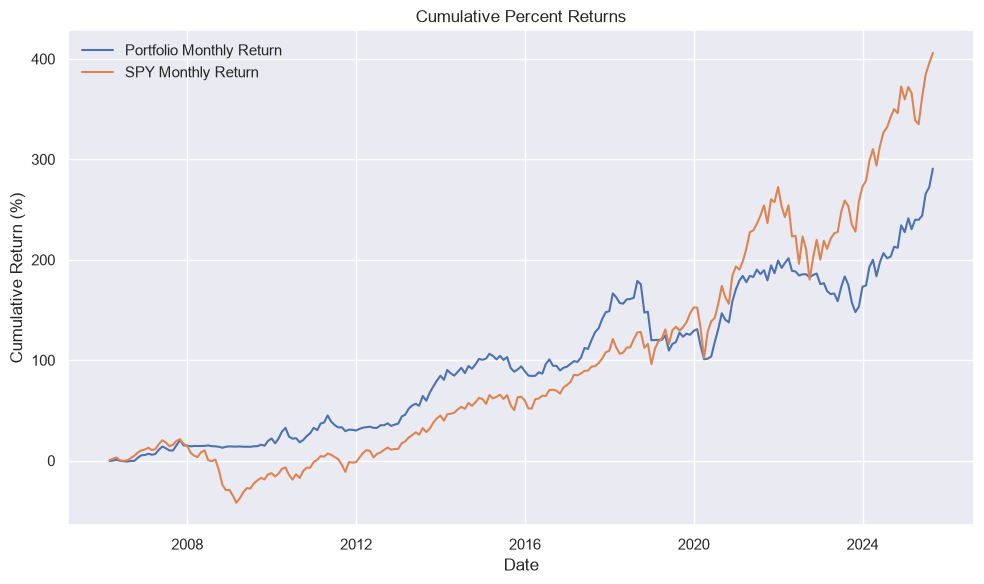

In [11]:
fn.cumulative_return_graph(backtest_monthly_returns, bt_start_date, bt_end_date)

Next, we will analyze how our strategy did in any given month.
The `seasonal_heatmap` function is a powerful visualization tool that let's you see how the startegy did month over month. This is a great way to see when our startegy did incredibly well, or identify the periods when it didn't do well.

The goal is to help us understand the behaviour of our strategy during different market environments.

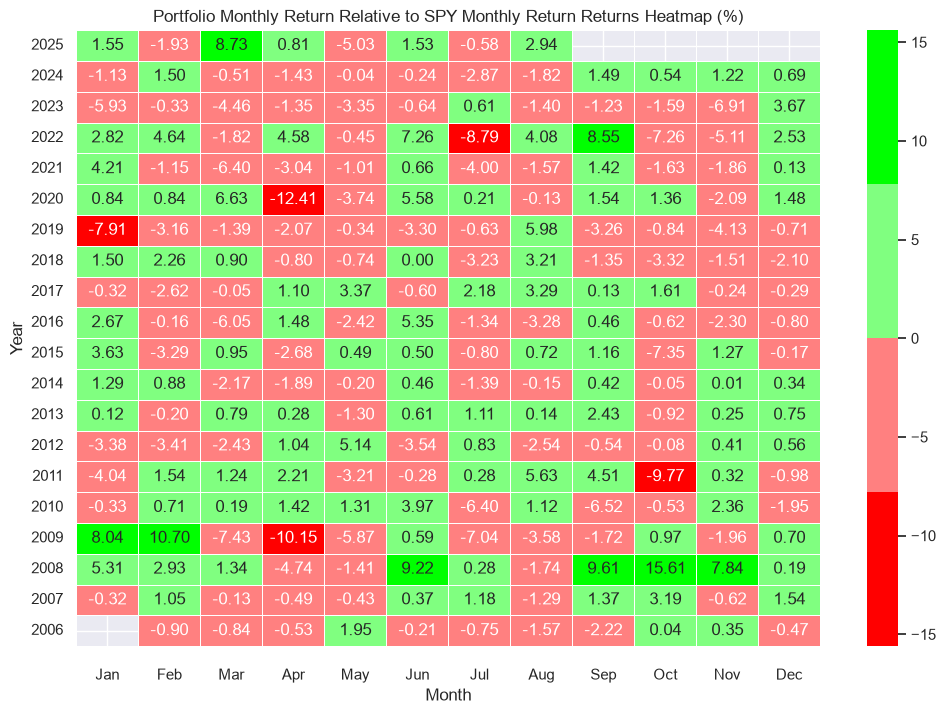

In [12]:
fn.seasonal_heatmap(
    backtest_monthly_returns,
    ticker='Portfolio Monthly Return',
    absolute=False,
    benchmark='SPY Monthly Return',
    frequency='M'
)

## Market Capture Ratios
Market capture ratios are statistics that measure how well an investment strategy performed relative to a benchmark index, specifically during periods when that benchmark was up (positive) versus when it was down (negative).

There are two main ratios:

- Up-Market Capture Ratio: Shows how much of the market's gains the strategy "captured." A ratio over 100% means the strategy outperformed the benchmark during up-periods.

- Down-Market Capture Ratio: Shows how much of the market's losses the strategy "captured." A ratio under 100% means the strategy lost less than the benchmark during down-periods (which is a good thing).

**Why They Are Important (Investment Behavior)**

These ratios are vital because they reveal the behavior and skill of a strategy, not just its overall return.

A strategy with an Up-Capture of 110% and a Down-Capture of 90% has a highly desirable, asymmetric return profile. It means it tends to "win more" in good times and "lose less" in bad times. This combination is a hallmark of a successful active strategy, as it protects capital during downturns while still participating in rallies.

The Role of the Benchmark

- They Are Relative: Capture ratios cannot exist without a benchmark. They are, by definition, a comparison to an index (like the S&P 500, which you use in your course).

- "Apples-to-Apples": The choice of benchmark determines whether the comparison is meaningful or deceptive. If you compare a high-risk U.S. tech-stock strategy to a low-risk government bond index, the capture ratios will be completely distorted and useless. The benchmark must be an appropriate "ruler" for what you're measuring (e.g., U.S. large-cap stocks vs. S&P 500).

In [13]:
# Market capture ratio
mkt_capture_ratio = fn.market_capture_ratio(
    backtest_monthly_returns,
    bt_start_date,
    bt_end_date,
    frequency='M'
)

mkt_capture_ratio

,Up Market Capture Ratio,Down Market Capture Ratio
Portfolio Monthly Return,58.59,46.36
SPY Monthly Return,100.00,100.00


## Conclusion

Congratulations! You are now ready to go out and build your own momentum strategy!

We sincerely hope you enjoyed this course. A lot of effort and time went into creating this, and if you liked it, please give it a great review, leave comments, and share it.
We truly thank you for spending your time with us, and we hope to see you in our other courses found on Udemy or at [digitalhub-labs.com](https://).



## Disclaimers

**Please Read Carefully**
- For Educational Purposes Only: The content in this course, including all code, strategies, and analysis, is provided for educational and informational purposes only.
- Not Investment Advice: The information presented is not, and should not be construed as, investment advice, financial advice, trading advice, or a recommendation to buy or sell any security. All investment decisions are your own.
- No Guarantees & Past Performance: Trading and investing involve substantial risk. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future results. There is no guarantee that any strategy presented here will be profitable.
- Assumption of Risk: You, and you alone, are solely responsible for any investment decisions you make and for any and all losses that may result from them. The instructor and Digital Hub Insights LLC will not be held responsible for any investment losses you may incur.
- Consult a Professional: Always consult with a licensed financial advisor and/or tax professional to determine the suitability of any investment.




---
## Signal Sensitivity: top_n Comparison

The chart earlier showed the strategy lagging SPY. Before touching execution/risk code further, we test
whether the **signal itself** is too diversified. `top_n=10` was selected out of a multi-asset universe
(equities + bonds + commodities) in Notebook 2, that's a mild tilt, not a concentrated momentum bet,
and it lets non-equity ETFs (TLT, GLD, USO...) dilute returns during an equity bull market.

This cell regenerates the monthly signal at `top_n = 3, 5, 10` directly from the already-loaded
`daily_prices`, runs each through the real risk-managed `run_custom_backtest`, and compares them
side-by-side against SPY, so we can see how much of the gap is signal concentration vs. execution.


2026-07-18 14:17:42,931 | INFO | Backtest period: 2006-01-31 to 2025-08-29 | 235 rebalance dates.


2026-07-18 14:17:45,028 | INFO | Backtest complete. Total commission: $0.00 | Total slippage cost (est.): $379.92


2026-07-18 14:17:45,047 | INFO | ============================================================


2026-07-18 14:17:45,048 | INFO | TEARSHEET


2026-07-18 14:17:45,049 | INFO | CAGR:                 8.03%


...

2026-07-18 14:17:52,219 | INFO | Total Est. Slippage:  $171.31


2026-07-18 14:17:52,220 | INFO | Total Turnover ($):   $232452.35


2026-07-18 14:17:52,220 | INFO | ============================================================


top_n=10: done, 235 months


,CAGR,AnnVol,Sharpe,MaxDrawdown,Beta,Alpha
top_n,,,,,,
3,0.080342,0.149459,0.592236,-0.306681,0.381624,0.052329
5,0.070719,0.121207,0.625492,-0.323650,0.407137,0.037209
10,0.067884,0.101653,0.698557,-0.274773,0.433339,0.029921


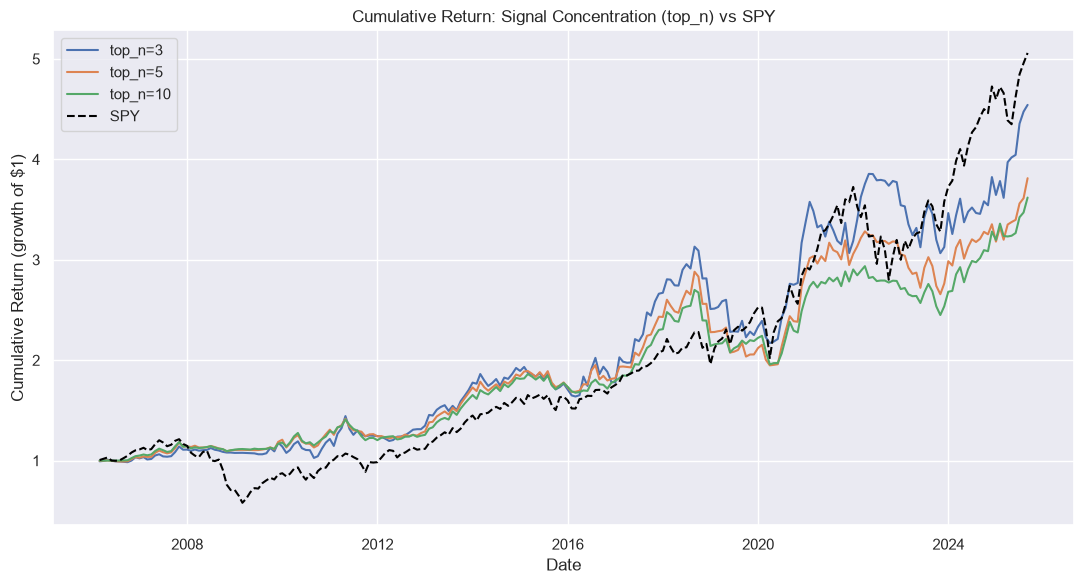

In [14]:
# --- Reconstruct the signal-generation functions from Notebook 2 (kept local so this
#     cell is self-contained and doesn't require re-running notebook 2) ---

def calculate_period_returns(df_prices, period: int = 12):
    # pandas 2.x removed fill_method from pct_change(); forward-fill explicitly first
    return df_prices.ffill().pct_change(periods=period)

def assign_ranks(df_returns):
    return df_returns.rank(axis=1, ascending=False)

def get_top_etfs(df_ranks, top_n=10):
    return df_ranks.apply(lambda x: x.nsmallest(top_n).index.tolist(), axis=1)


# --- Build a monthly close-price panel from the daily data already loaded above ---
if isinstance(daily_prices.columns, pd.MultiIndex):
    fields = daily_prices.columns.get_level_values(1)
    close_field = next((f for f in fields.unique() if str(f).lower() in ('close', 'adj close', 'adjclose')), None)
    if close_field is None:
        raise ValueError(f"No close-like field found. Available fields: {fields.unique().tolist()}")
    close_daily = daily_prices.xs(close_field, level=1, axis=1)
else:
    close_daily = daily_prices

close_monthly = close_daily.resample('ME').last()

lookback_period = 12  # matches Notebook 2's default
momentum_scores = calculate_period_returns(close_monthly, period=lookback_period).dropna(how='all')
df_ranks = assign_ranks(momentum_scores)


# --- Run the risk-managed backtest at several top_n values ---
top_n_values = [3, 5, 10]
results = {}
tearsheets = {}

for n in top_n_values:
    signal_n = get_top_etfs(df_ranks, top_n=n)
    cfg = BacktestConfig(
        holding_period=1,
        initial_capital=1000.00,
        commission=0,
        drift_threshold=0.03,
        min_trade_size=25.0,
        max_position_weight=max(0.35, 1.0 / n),  # don't let the cap fight a concentrated book
    )
    df_n = run_custom_backtest(signal_n, daily_prices,
                                holding_period=cfg.holding_period,
                                commission=cfg.commission,
                                initial_capital=cfg.initial_capital,
                                drift_threshold=cfg.drift_threshold,
                                min_trade_size=cfg.min_trade_size,
                                max_position_weight=cfg.max_position_weight)
    results[n] = df_n
    tearsheets[n] = df_n.attrs.get('tearsheet', {})
    print(f"top_n={n}: done, {len(df_n)} months")


# --- Comparison table ---
summary = pd.DataFrame(tearsheets).T
summary.index.name = 'top_n'
display(summary[['CAGR', 'AnnVol', 'Sharpe', 'MaxDrawdown', 'Beta', 'Alpha']])


# --- Cumulative return chart: each top_n vs SPY ---
plt.figure(figsize=(11, 6))
for n in top_n_values:
    plt.plot(results[n].index, results[n]['Portfolio Cumulative Return'], label=f'top_n={n}')
spy_col = [c for c in results[top_n_values[0]].columns if 'SPY Cumulative' in c]
if spy_col:
    plt.plot(results[top_n_values[0]].index, results[top_n_values[0]][spy_col[0]],
              label='SPY', color='black', linestyle='--')
plt.title('Cumulative Return: Signal Concentration (top_n) vs SPY')
plt.ylabel('Cumulative Return (growth of $1)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


---
## Multi-Scenario Equity Curve: Concentration and Cadence vs SPY

Extends the top_n comparison above along a second axis, `holding_period` (rebalance cadence).
Three scenarios, chosen because they're the same structural dimensions (signal concentration,
rebalance cadence) already explored above, not a search across many configs for a flattering
result:

- **Default**: `top_n=10, holding_period=1`, matches `config.example.yaml`'s shipped default.
- **Concentrated**: `top_n=5, holding_period=1`, matches this project's own long-term
  recommended preset, see `docs/RISK_CONSTRAINTS.md`.
- **Concentrated + Quarterly**: `top_n=5, holding_period=3`, a lower-turnover variant.

All three reuse `df_ranks` (lookback_period=12) already built above, and the same
`daily_prices`/`random_seed`, only `top_n` and `holding_period` vary. This is the source cell
for `docs/img/equity_curve.png`, the project README's hero chart, replacing a hand-exported
earlier version with a real, reproducible, multi-scenario comparison.

2026-07-18 14:17:53,258 | INFO | Backtest period: 2006-01-31 to 2025-08-29 | 235 rebalance dates.


2026-07-18 14:17:56,441 | INFO | Backtest complete. Total commission: $0.00 | Total slippage cost (est.): $171.31


2026-07-18 14:17:56,486 | INFO | ============================================================


2026-07-18 14:17:56,487 | INFO | TEARSHEET


2026-07-18 14:17:56,488 | INFO | CAGR:                 6.79%


...

2026-07-18 14:18:02,143 | INFO | Total Est. Slippage:  $146.50


2026-07-18 14:18:02,144 | INFO | Total Turnover ($):   $137329.61


2026-07-18 14:18:02,144 | INFO | ============================================================


Concentrated + Quarterly (top_n=5, hold=3mo): done, 235 months


,CAGR,AnnVol,Sharpe,MaxDrawdown,Beta,Alpha
Scenario,,,,,,
"Default (top_n=10, hold=1mo)",0.067884,0.101653,0.698557,-0.274773,0.433339,0.029921
"Concentrated (top_n=5, hold=1mo)",0.070719,0.121207,0.625492,-0.323650,0.407137,0.037209
"Concentrated + Quarterly (top_n=5, hold=3mo)",0.066428,0.121936,0.589555,-0.220347,0.427844,0.031320


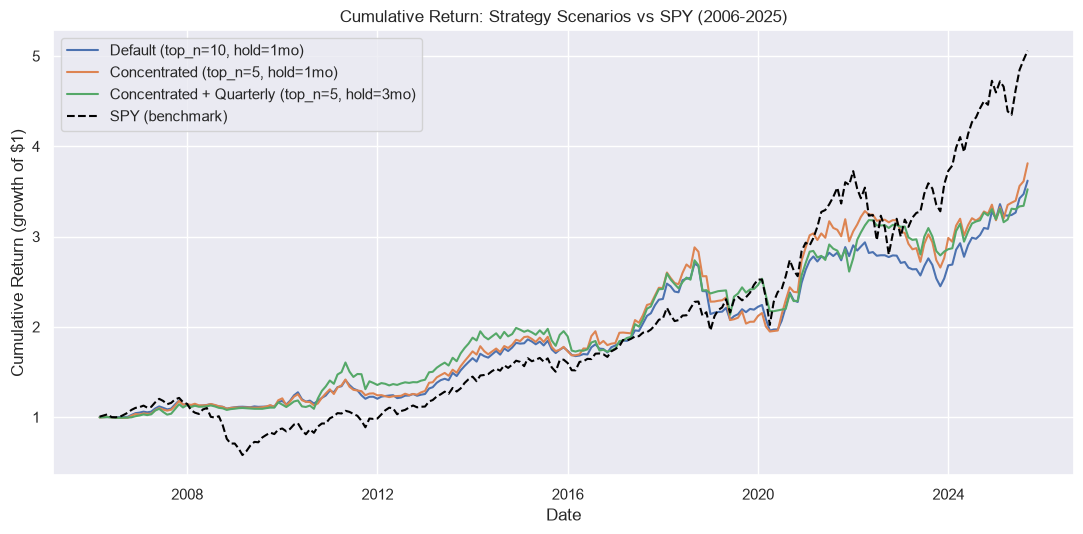

In [15]:
# --- Multi-scenario equity curve: several BacktestConfig scenarios vs SPY, one legend ---
# Reuses df_ranks (lookback_period=12) already built in the top_n comparison cell above.

scenarios = {
    'Default (top_n=10, hold=1mo)': dict(top_n=10, holding_period=1),
    'Concentrated (top_n=5, hold=1mo)': dict(top_n=5, holding_period=1),
    'Concentrated + Quarterly (top_n=5, hold=3mo)': dict(top_n=5, holding_period=3),
}

scenario_results = {}
scenario_tearsheets = {}

for label, params in scenarios.items():
    n = params['top_n']
    signal_n = get_top_etfs(df_ranks, top_n=n)
    df_scenario = run_custom_backtest(
        signal_n, daily_prices,
        holding_period=params['holding_period'],
        commission=0.0,
        initial_capital=1000.00,
        drift_threshold=0.03,
        min_trade_size=25.0,
        max_position_weight=max(0.35, 1.0 / n),
        random_seed=42,
    )
    scenario_results[label] = df_scenario
    scenario_tearsheets[label] = df_scenario.attrs.get('tearsheet', {})
    print(f"{label}: done, {len(df_scenario)} months")


# --- Comparison table ---
scenario_summary = pd.DataFrame(scenario_tearsheets).T
scenario_summary.index.name = 'Scenario'
display(scenario_summary[['CAGR', 'AnnVol', 'Sharpe', 'MaxDrawdown', 'Beta', 'Alpha']])


# --- Cumulative return chart: each scenario vs SPY, saved to docs/img/equity_curve.png ---
fig, ax = plt.subplots(figsize=(11, 5.5))
first_label = next(iter(scenarios))
for label in scenarios:
    ax.plot(scenario_results[label].index, scenario_results[label]['Portfolio Cumulative Return'], label=label)
spy_col = [c for c in scenario_results[first_label].columns if 'SPY Cumulative' in c]
if spy_col:
    ax.plot(scenario_results[first_label].index, scenario_results[first_label][spy_col[0]],
            label='SPY (benchmark)', color='black', linestyle='--')
start_year = scenario_results[first_label].index[0].year
end_year = scenario_results[first_label].index[-1].year
ax.set_title(f'Cumulative Return: Strategy Scenarios vs SPY ({start_year}-{end_year})')
ax.set_ylabel('Cumulative Return (growth of $1)')
ax.set_xlabel('Date')
ax.legend()
fig.tight_layout()
fig.savefig('../../docs/img/equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Strengthening the Result: Factor Decomposition, Regime Breakdown, Significance

Three checks a fund would run before trusting `backtest_df`'s headline numbers:

1. **Factor decomposition**, is the outperformance real alpha, or just static beta exposure
   (e.g. usually overweight equities) dressed up as skill?
2. **Regime breakdown**, does it actually protect capital in 2008/2020/2022, or just ride the
   same bull market SPY did?
3. **Significance test**, is the return spread vs. SPY distinguishable from noise?


In [16]:
from momentum_trading.core import functions_quant_extensions as fnx

strat_ret = backtest_df['Portfolio Monthly Return']
bench_col = [c for c in backtest_df.columns if 'SPY Monthly Return' in c][0]
bench_ret = backtest_df[bench_col]

# --- 1. Factor decomposition: regress strategy on available benchmark/factor returns ---
# Add more columns to factor_returns (e.g. TLT, GLD monthly returns) if you have them handy
# for a fuller decomposition than just equity beta.
# Multi-factor: SPY (equity beta) + TLT (rates) + GLD (commodities) if present in your universe
factor_cols = {}
for ticker in ['SPY', 'TLT', 'GLD']:
    if isinstance(daily_prices.columns, pd.MultiIndex):
        fields = daily_prices.columns.get_level_values(1)
        cf = next((f for f in fields.unique() if str(f).lower() in ('close','adj close','adjclose')), None)
        px = daily_prices.xs(cf, level=1, axis=1) if cf else None
    else:
        px = daily_prices
    if px is not None and ticker in px.columns:
        factor_cols[ticker] = px[ticker].resample('ME').last().pct_change()
factor_returns = pd.DataFrame(factor_cols)
print(f"Factors used: {list(factor_returns.columns)}")
decomp = fnx.factor_decomposition(strat_ret, factor_returns)
print("--- Factor Decomposition ---")
print(f"Annualized alpha: {decomp['alpha_annualized']:.2%}  (t-stat: {decomp['alpha_tstat']:.2f})")
print(f"Betas: {decomp['betas']}")
print(f"R-squared: {decomp['r_squared']:.2f}")
print("A high R-squared + insignificant alpha (|t-stat| < ~2) means the 'edge' is mostly beta, not skill.\n")

# --- 2. Regime-conditional breakdown ---
regime_table = fnx.regime_breakdown(strat_ret, bench_ret)
print("--- Regime Breakdown ---")
display(regime_table)

# --- 3. Significance of the outperformance spread ---
sig = fnx.bootstrap_spread_significance(strat_ret, bench_ret, block_size=6)
print("\n--- Significance of Return Spread vs. SPY ---")
print(f"Mean monthly spread: {sig['mean_monthly_spread']:.2%}  (annualized: {sig['annualized_spread']:.2%})")
print(f"90% CI: [{sig['ci_low_90']:.2%}, {sig['ci_high_90']:.2%}]")
print(f"Approx p-value: {sig['p_value_approx']:.3f}")
print("If the 90% CI straddles zero, the spread isn't statistically distinguishable from noise.")


Factors used: ['SPY', 'TLT', 'GLD']
--- Factor Decomposition ---
Annualized alpha: 1.94%  (t-stat: 1.00)
Betas: {'SPY': np.float64(0.4250902031783958), 'TLT': np.float64(0.028653356448879008), 'GLD': np.float64(0.06478431132435603)}
R-squared: 0.39
A high R-squared + insignificant alpha (|t-stat| < ~2) means the 'edge' is mostly beta, not skill.

--- Regime Breakdown ---


,Strategy_Return,Benchmark_Return,Strategy_MaxDD,Benchmark_MaxDD,Outperformance
Regime,,,,,
Full Sample,2.907459,4.059216,-0.279800,-0.521953,-1.151756
GFC (2008),-0.009431,-0.494357,-0.020375,-0.473245,0.484927
COVID Crash (2020),-0.111451,-0.054496,-0.129961,-0.198862,-0.056955
2022 Bear Market,-0.078382,-0.194816,-0.085709,-0.209149,0.116434



--- Significance of Return Spread vs. SPY ---
Mean monthly spread: -0.16%  (annualized: -1.95%)
90% CI: [-0.58%, 0.27%]
Approx p-value: 0.248
If the 90% CI straddles zero, the spread isn't statistically distinguishable from noise.
